Modified from "Using Deep Learning for Flexible and Scalable Earthquake Forecasting"  
Reference: [Zenodo](https://zenodo.org/records/8161777)

In [51]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path
import torch
import src  
import matplotlib.pyplot as plt
from src.utils.utils import set_seed
import src.data.catalog as catalog
import src.catalogs as catalogs
import functools
import os
import importlib
sys.path.append(str(Path.cwd().parent))
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
set_seed(0) 

In [ ]:
checkpoint_dir  =  Path("../checkpoints/etas_20251231-123806") 
checkpoint_path1 = checkpoint_dir/ "best_model_1.pth"
checkpoint_dir2 = Path("../checkpoints/etas_20251221-224107") 
checkpoint_path2 = checkpoint_dir2/ "last_model_1.pth"

## Loading a trained model

In [53]:
from src.models.builders import ModelBuilder
from src.train.config_setup import load_and_prepare_model
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model, args = load_and_prepare_model(checkpoint_path=checkpoint_path1,device=device)
# model2,_ = load_and_prepare_model(checkpoint_path=checkpoint_path2,device=device)

load_specific_parts: None
Checkpoint loaded: <All keys matched successfully>
hyperparameters: {'model': 'etas', 'num_event_types': 1, 'pad_token_id': 1, 'task_type': 'tpp', 'bg_model': 'mamba', 'bg_model_cfg': {'d_feature': 1, 'd_state': 64, 'd_model': 16, 'model_type': 'mamba', 'scale_init': 200.0}, 'bg_learning_rate': 0.0005, 'base_rate_init': 0.26, 'batch_size': 1, 'accumulation_steps': 1, 'warmup_ratio': 0.1, 'learning_rate': 0.01, 'weight_decay': 0.005, 'scheduler_factor': None, 'scheduler_patience': None, 'scheduler_threshold': None, 'scheduler_min_lr': 1e-06, 'scheduler_type': 'step_warmup', 'step_lr_step_size_ratio': 0.2, 'step_lr_gamma': 0.8, 'dim': 1, 'epochs': 2000, 'save_dir': 'checkpoints/etas_20251226-124958', 'cuda_id': '0', 'dataset': 'PNR', 'seed': 0, 'minibatch_training': False, 'split_by_time': True, 'time_order': ['train', 'val', 'test'], 'catalog_cfg': {'freq': '1D', 'mag_completeness': -1.5, 'region_split': ['1z', '2', '2'], 'train_start_ts': '2018-10-22', 'val_st

In [4]:
# model.bg_model = model2.bg_model

In [54]:
if model.bg_model is not None:
   print(f" model.bg_model._scale: {model.bg_model._scale}")

 model.bg_model._scale: 191.754150390625


In [55]:
model.print_params()

ETAS model parameters:
  p = 2.2798984660694694
  c = 0.010671899699944377
  mu = 0.14760213888158963
  k = 0.0025074280623073545
  K = 0.6541891583928007
  alpha = 0.2427021195082425
  alpha_e = 0.5588422824177386
  b = 1.2478536367416382
  M_c = -1.5
  M_m = 10.0


## Loading the catalog

In [56]:
args.catalog_cfg

{'freq': '1D', 'mag_completeness': -1.5, 'region_split': ['1z', '2', '2'], 'train_start_ts': '2018-10-22', 'val_start_ts': '2019-08-20', 'test_start_ts': '2019-08-24'}

In [57]:
catalog_ds_class = catalog.Catalog.by_name(f"{args.dataset}-Standard")
catalog_cfg = getattr(args, 'catalog_cfg', {})
catalog_ds = catalog_ds_class(root_dir=f'../data/{args.dataset}/raw', **catalog_cfg)

Loading existing catalog from /root/autodl-tmp/chuandian_eq/data/PNR_1z/raw/2e94e6c6.
Loading existing catalog from /root/autodl-tmp/chuandian_eq/data/PNR_2/raw/0727b337.
Loading existing catalog from /root/autodl-tmp/chuandian_eq/data/PNR/raw/87ab64f0.


In [58]:
catalog_ds.train[0].arrival_times

tensor([ 1.2314,  1.2320,  1.2326,  ..., 64.1283, 64.1326, 64.1675])

## Prepare the data

We trained the TPP model using the `train` and `val` sequences. Now we will use the unseen section of the `test` sequence (in orange) to evaluate forecasting performance of the model.

<Axes: xlabel='Arrival time (days)', ylabel='Magnitude'>

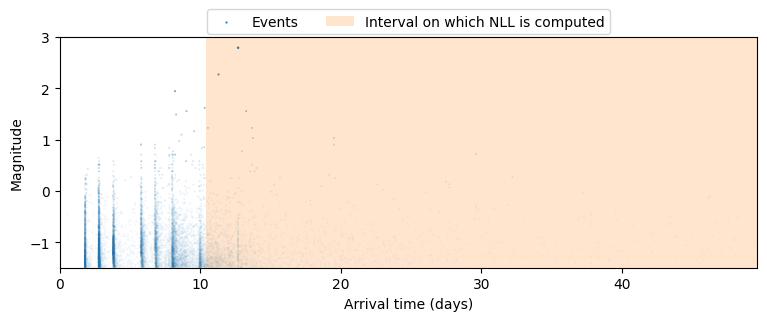

In [59]:
from src.utils.visualization import visualize_sequence
test_seq = catalog_ds.test[0]
train_seq = catalog_ds.train[0]
val_seq  = catalog_ds.val[0]
visualize_sequence(test_seq, show_nll=True)

In [60]:
test_batch = src.data.Batch.from_list([test_seq])
test_batch.to(device)
train_batch = src.data.Batch.from_list([train_seq])
train_batch.to(device)
val_batch = src.data.Batch.from_list([val_seq])
val_batch.to(device)

Batch(
  inter_times: [1, 14461],
  arrival_times: [1, 14461],
  t_start: [1],
  t_end: [1],
  t_nll_start: [1],
  nll_event_mask: [1, 14461],
  input_mask: [1, 14461],
  start_idx: [1],
  end_idx: [1],
  non_pad_mask: [1, 14461],
  type_seq: [1, 14461],
  mag: [1, 14461],
  loc: [1, 14461, 2],
  depth: [1, 14461],
  time_series: [1, 14911, 1],
  time_series_times: [1, 14911]
)

In [61]:
batch = train_batch

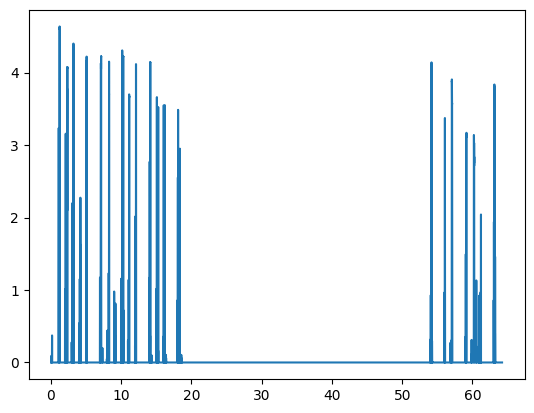

In [62]:
plt.plot(batch.time_series_times.squeeze().cpu().detach().numpy(),batch.time_series.squeeze().cpu().detach().numpy(),label='test')

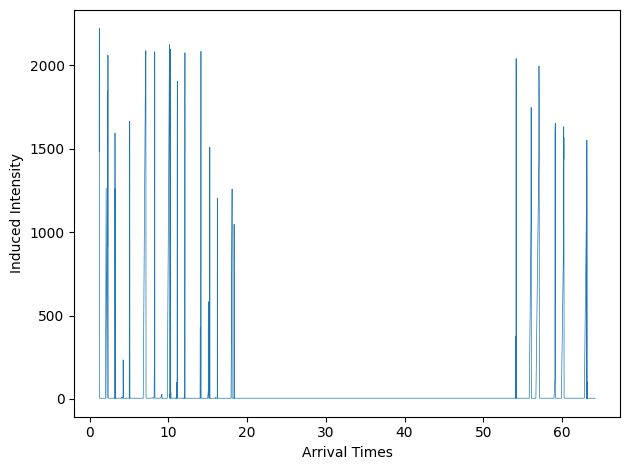

In [63]:
if model.bg_model is not None:
    f_intensity= model.bg_model.intensity(batch)
    plt.plot(
        batch.arrival_times.reshape(-1).detach().cpu().numpy(),
        f_intensity.reshape(-1).detach().cpu().numpy(),
        linewidth=0.5,
        color='tab:blue'
    )
    plt.xlabel('Arrival Times')
    plt.ylabel('Induced Intensity')
    plt.tight_layout()
    plt.savefig(checkpoint_dir/'induced_intensity.png')

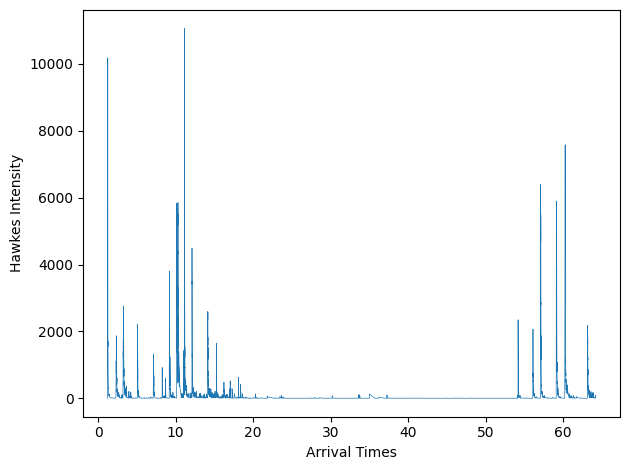

In [64]:
### rtpp
# context = model.get_context(batch)
# inter_time_dist = model.get_inter_time_dist(context)
# log_h_intensity = inter_time_dist.log_hazard(batch.inter_times.clamp_min(1e-10))
# h_intensity = torch.exp(log_h_intensity)
# h_intensity_copied = torch.where(h_intensity > 100000, torch.tensor(0.0, device=h_intensity.device), h_intensity)

# window = 20  # smoothing window size
# arrival_times_np = batch.arrival_times.detach().cpu().numpy().ravel()
# raw_np = h_intensity_copied.detach().cpu().numpy().ravel()
# smoothed = np.convolve(raw_np, np.ones(window) / window, mode='same')

# plt.xlabel('Arrival Times')
# plt.ylabel('History Intensity')
# # plt.plot(arrival_times_np, raw_np, linewidth=0.5, color='tab:blue', label='Raw')
# plt.plot(arrival_times_np, smoothed, linewidth=1.0, color='tab:red', label='Smoothed')
# plt.legend()
# plt.tight_layout()
### etas
h_intensity= model.h_intensity(batch)
plt.plot(
    batch.arrival_times.reshape(-1)[:-1].detach().cpu().numpy(),
    h_intensity.reshape(-1).detach().cpu().numpy(),
    linewidth=0.5,
    color='tab:blue'
)
plt.xlabel('Arrival Times')
plt.ylabel('Hawkes Intensity')
plt.tight_layout()
plt.savefig(checkpoint_dir/'hawkes_intensity.png')

In [65]:
(h_intensity > 1000).sum().item()

3987

We would like to generate a 30-day forecast for the interval `[13000, 13030]`. For this, we select two subsequences:
- `past_seq`: Contains events from `[0, 13000]`, is used to condition the model
- `observed_seq`: Contains actually observed events from `[13000, 13030]`.

In [16]:
t_forecast = 2 # 1460
duration = 1 # 7 30
num_samples = 10000 # 10000

# Past events that we condition on
past_seq = test_seq.get_subsequence(0, t_forecast,reset_t_nll_to_end=True) #  3500
observed_seq = test_seq.get_subsequence(t_forecast, t_forecast + duration,reset_t_nll_to_end=True)

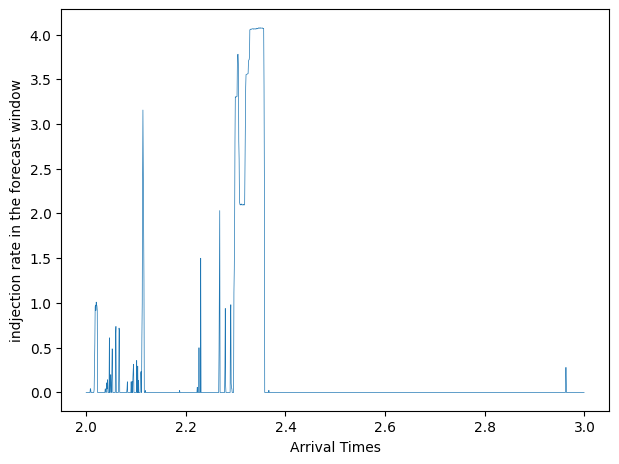

In [17]:
mask  = (test_seq.time_series_times >= t_forecast) & (test_seq.time_series_times < t_forecast + duration)
future_time_series = test_seq.time_series[mask]
future_time_series_times = test_seq.time_series_times[mask]
plt.xlabel('Arrival Times')
plt.ylabel('indjection rate in the forecast window')
plt.tight_layout()
plt.plot(future_time_series_times,
          future_time_series.reshape(-1).detach().cpu().numpy(),
           linewidth=0.5,
         color='tab:blue')

## Generate the forecast

In [18]:
past_batch = src.data.Batch.from_list([past_seq.float()])

In [19]:
past_seq

Sequence(
  inter_times: [350],
  arrival_times: [349],
  t_start: 0.0,
  t_end: 2.0,
  t_nll_start: 1.9,
  mag: [349],
  loc: [349, 2],
  depth: [349],
  time_series: [2825, 1],
  time_series_times: [2825]
)

In [20]:
if torch.cuda.is_available():
    model.to('cuda:0')
    past_seq.to('cuda:0')

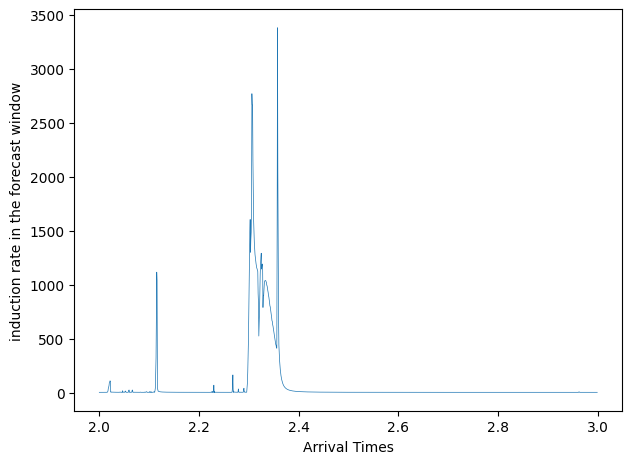

In [21]:
if model.bg_model is not None:
    model.bg_model.cache_batch(time_series=test_seq.time_series.unsqueeze(0), time_series_times=test_seq.time_series_times.unsqueeze(0))
    model.bg_model.ts_batch_cache
    times_all = test_seq.time_series_times
    mask = (times_all >= t_forecast) & (times_all < t_forecast + duration)
    f_intensity = model.bg_model.intensity(ts_batch=model.bg_model.ts_batch_cache,t_query=times_all[mask].unsqueeze(0))
    plt.xlabel('Arrival Times')
    plt.ylabel('induction rate in the forecast window')
    plt.tight_layout()
    plt.plot(times_all[mask], f_intensity.reshape(-1).detach().cpu().numpy(), linewidth=0.5, color='tab:blue')

In [22]:
observed_seq.arrival_times

tensor([2.0329, 2.1140, 2.2345, 2.3053, 2.3079, 2.3081, 2.3119, 2.3119, 2.3192,
        2.3203, 2.3211, 2.3215, 2.3221, 2.3245, 2.3246, 2.3253, 2.3263, 2.3271,
        2.3280, 2.3284, 2.3285, 2.3293, 2.3296, 2.3308, 2.3308, 2.3313, 2.3314,
        2.3315, 2.3322, 2.3324, 2.3337, 2.3344, 2.3349, 2.3353, 2.3361, 2.3368,
        2.3373, 2.3380, 2.3380, 2.3382, 2.3386, 2.3388, 2.3395, 2.3419, 2.3423,
        2.3424, 2.3433, 2.3433, 2.3439, 2.3450, 2.3454, 2.3465, 2.3485, 2.3494,
        2.3496, 2.3511, 2.3512, 2.3513, 2.3516, 2.3518, 2.3519, 2.3527, 2.3529,
        2.3535, 2.3543, 2.3545, 2.3555, 2.3560, 2.3563, 2.3566, 2.3567, 2.3568,
        2.3569, 2.3572, 2.3573, 2.3576, 2.3581, 2.3581, 2.3583, 2.3584, 2.3586,
        2.3591, 2.3595, 2.3596, 2.3601, 2.3601, 2.3601, 2.3604, 2.3615, 2.3618,
        2.3626, 2.3628, 2.3630, 2.3636, 2.3638, 2.3644, 2.3648, 2.3651, 2.3660,
        2.3667, 2.3667, 2.3678, 2.3678, 2.3683, 2.3708, 2.3710, 2.3711, 2.3772,
        2.3777, 2.3777, 2.3798, 2.3817, 

202

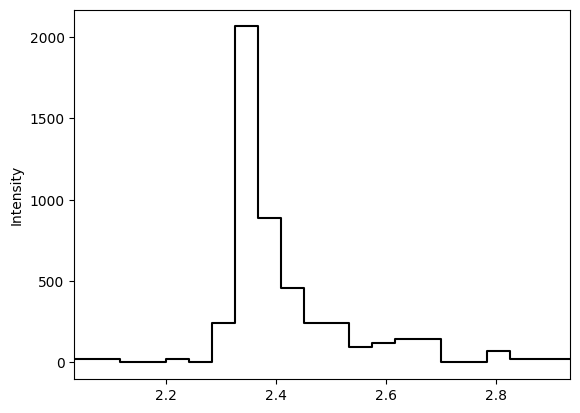

In [23]:
from src.utils.visualization import  plot_intensity
plot_intensity(observed_seq,dt=1/24)
len(observed_seq)

In [24]:
if model.bg_model is not None:
    model.bg_model.cache_batch(time_series=test_seq.time_series.unsqueeze(0), time_series_times=test_seq.time_series_times.unsqueeze(0))

In [25]:
if model.bg_model is not None:
    no = model.bg_model.forecast_count(t_forecast, t_forecast + duration)
    print(f"Forecasted background count from {t_forecast} to {t_forecast + duration}: {no}")
    # model.bg_model.forecast_count(t_forecast+5, t_forecast + 10)

Forecasted background count from 2 to 3: 80.76608276367188


In [26]:
# model.bg_model.set_scale(200)   
# model.bg_model._scale   
model.M_m = torch.tensor(6.5)
# model.set_params(mu=0.26,c=0.58,p=1.51,K=0.77,alpha_e=0.66)
model.print_params()

ETAS model parameters:
  p = 2.012207940558003
  c = 0.004334559894616285
  mu = 0.12350356012699254
  k = 0.002749546662745398
  K = 0.6697217156037166
  alpha = 0.2103566468210947
  alpha_e = 0.484364079182466
  b = 1.2355434894561768
  M_c = -1.5
  M_m = 6.5


In [27]:
model.nll_loss(train_batch), model.nll_loss(test_batch)

intensity max: 12693.599609375, f_intensity max: 4772.07177734375,mu max: 0.12350356012699254
intensity max: 8645.806640625, f_intensity max: 1774.813232421875,mu max: 0.12350356012699254


(tensor([-592.0541], device='cuda:0', grad_fn=<DivBackward0>),
 tensor([-1198.6285], device='cuda:0', grad_fn=<DivBackward0>))

In [42]:
set_seed(3) 
model.eval()  # Set the model to evaluation mode
all_forecasts = []
samples_per_batch = 10000
for _ in range(num_samples // samples_per_batch):
    # forecast = model.sample(batch_size=samples_per_batch, duration=duration, past_seq=past_seq, return_sequences=True, max_sample_len=4000)
    forecast = model.sample(batch_size=samples_per_batch, duration=duration, past_seq=past_seq, return_sequences=True)
    all_forecasts.extend(forecast)

  0%|          | 0/10000 [00:00<?, ?it/s]

/root/autodl-tmp/chuandian_eq/src/data/sequence.py:244: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(
/root/autodl-tmp/chuandian_eq/src/data/sequence.py:244: UserWarning: Found 2 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(
/root/autodl-tmp/chuandian_eq/src/data/sequence.py:244: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(
/root/autodl-tmp/chuandian_eq/src/data/sequence.py:244: UserWarning: Found 1 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(
/root/autodl-tmp/chuandian_eq/src/data/sequence.py:244: User

KeyboardInterrupt: 

In [29]:
zero_indices = []
for idx, fc in enumerate(all_forecasts):
    t = torch.as_tensor(fc.inter_times).cpu()
    if (t == 0).any():
        zero_indices.append(idx)

if zero_indices:
    print("Found zeros in inter_times at indices:", zero_indices)
else:
    print("No zeros found in inter_times of any forecast.")
print("Number of forecasts with zero inter_times:", len(zero_indices))

Found zeros in inter_times at indices: [21, 33, 37, 88, 117, 138, 161, 257, 266, 445, 566, 981, 1108, 1167, 1272, 1281, 1336, 1375, 1529, 1791, 1884, 1996, 2351, 2450, 2461, 2502, 2520, 2537, 2551, 2588, 2717, 2795, 2892, 3091, 3167, 3210, 3215, 3244, 3278, 3480, 3506, 3559, 3849, 3886, 3953, 3967, 4058, 4107, 4148, 4260, 4483, 4548, 4549, 4571, 4712, 4811, 4832, 5002, 5029, 5097, 5140, 5309, 5492, 5647, 5815, 5936, 5945, 6091, 6229, 6539, 6591, 6816, 6855, 7006, 7145, 7308, 7357, 7360, 7380, 7385, 7429, 7503, 7595, 7672, 7731, 7862, 7880, 8019, 8042, 8120, 8174, 8185, 8195, 8205, 8207, 8349, 8485, 8544, 8548, 8716, 8759, 8805, 8863, 8953, 9059, 9197, 9225, 9504, 9649, 9686, 9699, 9984]
Number of forecasts with zero inter_times: 112


`forecast` is a list, where each element is a `eq.data.Sequence` that represents a possible continuation of the catalog over the interval `[13000, 13030]`.

With the following function, we
- visualize 10 randomly chosen trajectories as a counting process
- plot the distribution of the total # of events in the forecast interval

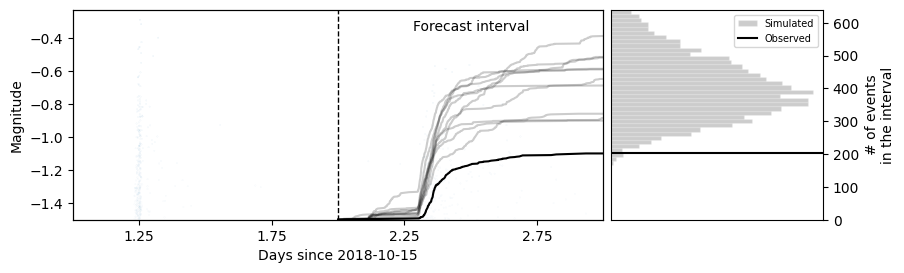

In [30]:
date_str = catalog_ds.metadata['start_ts'].strftime('%Y-%m-%d')
src.utils.visualization.visualize_trajectories(test_seq, all_forecasts,save_path=checkpoint_dir/"all_forecasts.pdf",figsize=(10,3),xlabel='Days since '+date_str,reset_t_nll_to_end=True)

In [31]:
import  src.utils.catalog_tests as catalog_tests

In [32]:
test_seq

Sequence(
  inter_times: [6141],
  arrival_times: [6140],
  t_start: 0.0,
  t_end: 64.208,
  t_nll_start: 59.667,
  mag: [6140],
  loc: [6140, 2],
  depth: [6140],
  time_series: [92404, 1],
  time_series_times: [92404]
)

N-test

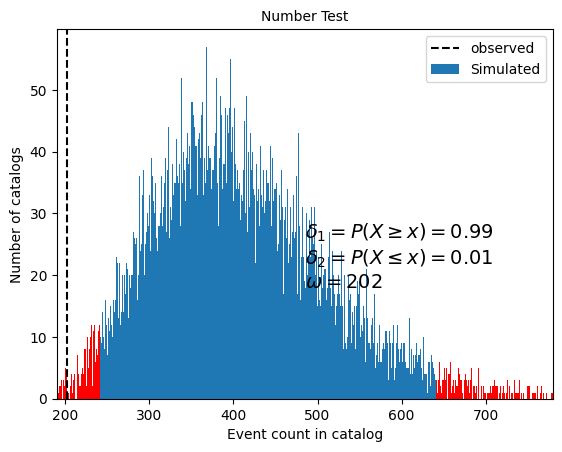

In [33]:
number_test_result = catalog_tests.run_number_test_result(
    event_counts=[len(fc) for fc in all_forecasts],
    obs_count=len(observed_seq),                   
    min_mw=catalog_ds.metadata['mag_completeness'],
    obs_name='observed',
    sim_name='Simulated',
    plot=False
)
ax= number_test_result.plot(plot_args={'figsize':(6.4,4.8),'tight_layout':False})
plt.savefig(checkpoint_dir/'n_test.pdf')

In [34]:
mag_max = [all_forecasts[i].mag.max().item() for i in range(len(all_forecasts))]
mag_min = [all_forecasts[i].mag.min().item() for i in range(len(all_forecasts))]
max(mag_max), min(mag_min)

(3.779848822361154, -1.4999999962021426)

In [35]:
observed_seq.mag.max().item(), observed_seq.mag.min().item()

(-0.5609999895095825, -1.4989999532699585)

M-test

In [36]:
config_dict = {
    'min_mw': catalog_ds.metadata['mag_completeness'],
    'max_mw': 5,
    'dmw': 0.01
}

magnitude_bins, distribution = catalog_tests.compute_magnitude_distribution(
    forecast[0].mag.cpu().numpy(), 
   **config_dict
)

In [37]:
import matplotlib
importlib.reload(src.utils.catalog_tests)

<module 'src.utils.catalog_tests' from '/root/autodl-tmp/chuandian_eq/src/utils/catalog_tests.py'>

In [38]:
get_counts = functools.partial(catalog_tests.compute_magnitude_distribution, **config_dict)
result_dict = catalog_tests.magnitude_test_from_counts(
    observed_catalog=observed_seq,
    forecast_catalogs=all_forecasts[:10],
    get_counts=lambda cat: get_counts(np.asarray(cat.mag.cpu()))[1],
    verbose=False,  
    debug=False
)

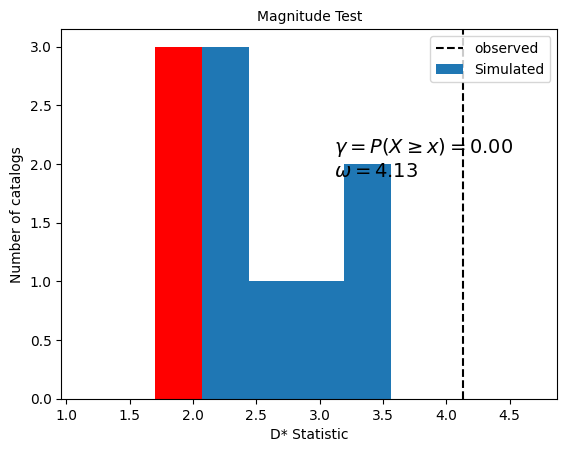

In [39]:
magnitude_test_result = catalog_tests.run_magnitude_test_result(
    result_dict=result_dict,
    obs_catalog_repr='obs',
   obs_name='observed',
    sim_name='Simulated',
    plot=False
)
magnitude_test_result.plot(plot_args={'figsize':(6.4,4.8),'tight_layout':False})
plt.savefig(checkpoint_dir/'m_test.pdf')

In [40]:
start = int(test_seq.arrival_times[0].item())
end   = int(test_seq.arrival_times[-1].item())

duration = 12
slide_step = 12
quantiles = (2.5, 97.5)
samples_per_batch = 1000

t_forecast_list = range(start + duration, end - duration, slide_step)

counts_list = []
q_list = []
mean_list = []
forecasts_counts_list = []

model.eval()

for t_forecast in t_forecast_list:
        t_end = min(t_forecast + duration, end)

        past_seq = test_seq.get_subsequence(
            0, t_forecast, reset_t_nll_to_end=True
        ).to(device)
        observed_seq = test_seq.get_subsequence(
            t_forecast, t_end, reset_t_nll_to_end=True
        ).to(device)

        all_forecasts = model.sample(
            batch_size=samples_per_batch,
            duration=(t_end - t_forecast),
            past_seq=past_seq,
            return_sequences=True
        )

        forecasts_counts = np.fromiter((len(fc) for fc in all_forecasts), dtype=np.int32)

        q = np.percentile(forecasts_counts, quantiles)
        mean = forecasts_counts.mean()

        q_list.append(q)
        mean_list.append(mean)
        true_counts = len(observed_seq)
        counts_list.append(true_counts)
        forecasts_counts_list.append(forecasts_counts)


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

/root/autodl-tmp/chuandian_eq/src/data/sequence.py:244: UserWarning: Found 3 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(
/root/autodl-tmp/chuandian_eq/src/data/sequence.py:244: UserWarning: Found 2 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(
/root/autodl-tmp/chuandian_eq/src/data/sequence.py:244: UserWarning: Found 3 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(
/root/autodl-tmp/chuandian_eq/src/data/sequence.py:244: UserWarning: Found 2 zero inter-event times in the sequence. This violates fundamental assumptions of TPP models and may lead to incorrect log-likelihood values.
  warnings.warn(
/root/autodl-tmp/chuandian_eq/src/data/sequence.py:244: User

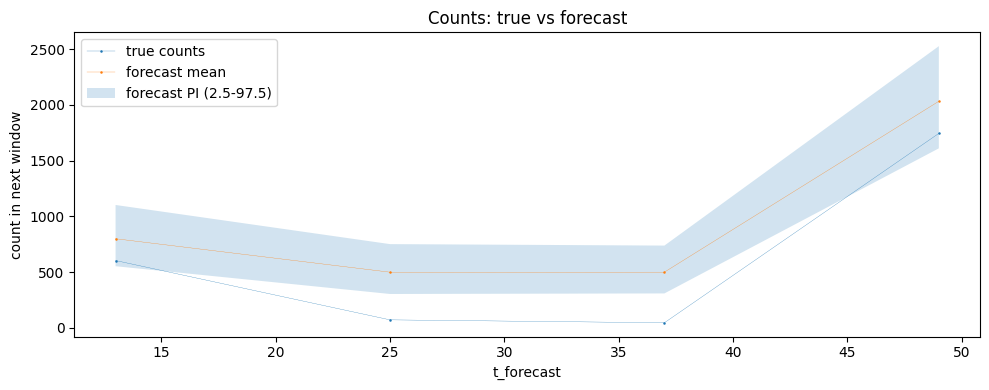

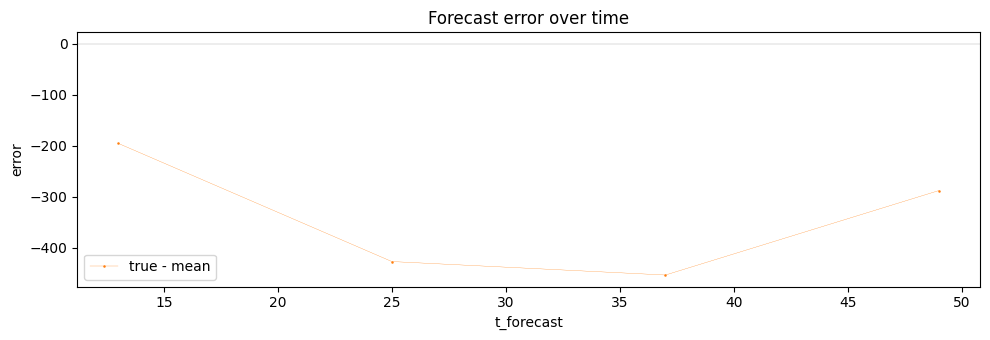

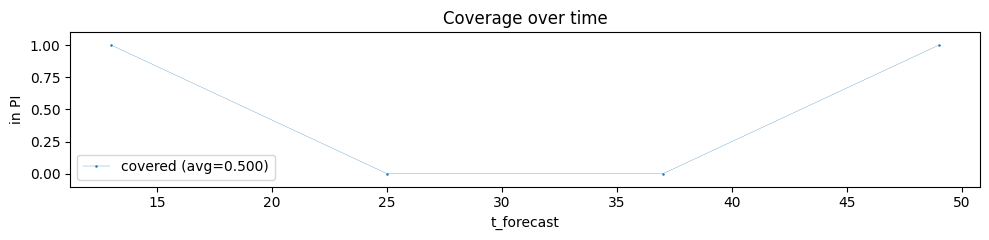

In [41]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array(list(t_forecast_list))
counts = np.array(counts_list)                  # shape: (T,)
means  = np.array(mean_list)                    # shape: (T,)
qs     = np.array(q_list)                       # shape: (T, 2)  -> [low, high]
q_low, q_high = qs[:, 0], qs[:, 1]

plt.figure(figsize=(10,4))
plt.plot(x, counts, label="true counts",linewidth=0.2,marker='o',markersize=0.8)
plt.plot(x, means,  label="forecast mean",linewidth=0.2,marker='o',markersize=0.8)
plt.fill_between(x, q_low, q_high, alpha=0.2, label="forecast PI (2.5-97.5)")
plt.xlabel("t_forecast")
plt.ylabel("count in next window")
plt.title("Counts: true vs forecast")
plt.legend()
plt.tight_layout()
plt.savefig(checkpoint_dir/'forecast_counts_over_time.png')
plt.show()

err = counts - means
plt.figure(figsize=(10,3.5))
plt.plot(x, err, label="true - mean",linewidth=0.2,marker='o',markersize=0.8,color='tab:orange')
plt.axhline(0,linewidth=0.2,color='gray')
plt.xlabel("t_forecast")
plt.ylabel("error")
plt.title("Forecast error over time")
plt.legend()
plt.tight_layout()
plt.savefig(checkpoint_dir/'forecast_error_over_time.png')
plt.show()


covered = (counts >= q_low) & (counts <= q_high)
coverage = covered.mean()
plt.figure(figsize=(10,2.5))
plt.plot(x, covered.astype(int), label=f"covered (avg={coverage:.3f})",linewidth=0.2,marker='o',markersize=0.8)
plt.ylim(-0.1, 1.1)
plt.xlabel("t_forecast")
plt.ylabel("in PI")
plt.title("Coverage over time")
plt.legend()
plt.tight_layout()
plt.show()
